In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import lightgbm as lgb
import optuna
from sklearn.metrics import root_mean_squared_error, r2_score

from scipy.stats import randint

import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("../inputs/dataset_v2_fs_top60.csv")
df = df.sort_values("fecha")

## Pre-procesamiento

In [14]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [15]:
df["fecha"].describe()

count                              644
mean     2024-04-29 09:25:42.857143040
min                2023-01-02 00:00:00
25%                2023-08-29 18:00:00
50%                2024-05-02 12:00:00
75%                2024-12-26 06:00:00
max                2025-08-28 00:00:00
Name: fecha, dtype: object

In [16]:
df = df.rename(columns={
    "merval_apertura_+1": "merval",
})

In [17]:
# Asegurarnos que no quedo ninguna fila con NA en la variable a predecir

print(df.loc[df['merval'].isna()].shape[0])

df = df.loc[df['merval'].notna()]

0


In [18]:
# chequeo de cuantos NAs tenemos en cada columna
pd.DataFrame(
    {'df (N)': df.isna().sum(),
    'df (%)': round(df.isna().sum()/df.shape[0]*100,1)}
)


,df (N),df (%)
fecha,0,0.0
merval_cierre_ma_3,0,0.0
emae_tendencia_ciclo_ma_5,0,0.0
merval_apertura,0,0.0
emae_desestacionalizado_lag2,0,0.0
...,...,...
m2_pct10,0,0.0
emae_tendencia_ciclo_diff3,0,0.0
tc_mayorista_pct10,0,0.0
m2_spec_centroid,0,0.0


In [19]:
# Eliminar filas con NaN creadas por los lags (las primeras 5 si usamos hasta lags de 5 dias)
df = df.dropna().copy()

In [20]:
y = df["merval"]
# X = df.drop(columns=["merval"]) # no estoy del todo seguro si tenemos que eliminar fecha
X = df.drop(columns=["merval","fecha"]) # no estoy del todo seguro si tenemos que eliminar fecha o si la convertimos a numerica

## Train-Test Split

In [21]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(515, 60)
(129, 60)


## Funcion objetivo para Optuna y Cross-Validation

In [22]:
max_lag = 5 # por el moving average 5

In [23]:
def objective(trial):
    # Espacios de búsqueda ajustados para ~515 filas de entrenamiento y 60 features
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 42,

        # Aprendizaje: rango más amplio con dataset más grande
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),

        # Complejidad del árbol: podemos permitir mayor complejidad
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 8),

        # Mínimos más exigentes con más datos
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 80),

        # Regularizaciones L1/L2
        "lambda_l1": trial.suggest_float("lambda_l1", 0.01, 3.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.01, 10.0, log=True),

        # Permitimos búsqueda de min_split_gain con más datos
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),

        # Submuestreo: rango similar pero podemos ser más agresivos
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),

        # Más árboles disponibles con dataset más grande
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "n_jobs": -1,
    }

    # --------- Ajustes dependientes (evitan configuraciones inválidas) ---------
    eff = params.copy()

    # Alinear num_leaves con max_depth: num_leaves <= 2**max_depth cuando max_depth>0
    if eff["max_depth"] > 0:
        eff["num_leaves"] = min(eff["num_leaves"], 2 ** eff["max_depth"])

    # Activar frecuencia de bagging si hay subsample<1
    if eff["subsample"] < 1.0:
        eff["subsample_freq"] = 1

    # --------------------------------------------------------------------------

    # Cross validation con más splits y test sets más grandes
    n_splits = 5  # Más folds con más datos
    test_size = 20  # ~1 mes de validación
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=max_lag)

    rmses = []
    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = lgb.LGBMRegressor(**eff)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        # Predicción usando los árboles óptimos según early stopping
        preds = model.predict(X_va, num_iteration=model.best_iteration_)
        rmse = mean_squared_error(y_va, preds, squared=False)
        rmses.append(rmse)

    return float(np.mean(rmses))

In [24]:
study = optuna.create_study(direction="minimize", study_name="lgbm_merval")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor RMSE CV promedio:", study.best_value)

[I 2025-11-09 23:05:10,006] A new study created in memory with name: lgbm_merval


  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

[I 2025-11-09 23:05:10,595] Trial 0 finished with value: 384880.2172400075 and parameters: {'learning_rate': 0.011021673526264502, 'num_leaves': 30, 'max_depth': 8, 'min_child_samples': 60, 'lambda_l1': 0.10410990438939004, 'lambda_l2': 0.06066984415589511, 'min_split_gain': 0.2788464173502224, 'subsample': 0.7657756123626647, 'colsample_bytree': 0.8810705636968059, 'n_estimators': 682}. Best is trial 0 with value: 384880.2172400075.


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

...

[I 2025-11-09 23:05:32,162] Trial 47 finished with value: 262924.425603642 and parameters: {'learning_rate': 0.09120504681978986, 'num_leaves': 50, 'max_depth': 7, 'min_child_samples': 27, 'lambda_l1': 1.290761973290356, 'lambda_l2': 0.43149250108996773, 'min_split_gain': 0.7972806125632184, 'subsample': 0.9751493362031434, 'colsample_bytree': 0.9212710826169259, 'n_estimators': 621}. Best is trial 21 with value: 241036.74413576414.


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

[I 2025-11-09 23:05:32,815] Trial 48 finished with value: 254060.16174595518 and parameters: {'learning_rate': 0.043321399035152364, 'num_leaves': 60, 'max_depth': 6, 'min_child_samples': 23, 'lambda_l1': 0.45432157103972026, 'lambda_l2': 0.08798218866094949, 'min_split_gain': 0.9471633775488113, 'subsample': 0.945518039974478, 'colsample_bytree': 0.7941757181303917, 'n_estimators': 686}. Best is trial 21 with value: 241036.74413576414.


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[I 2025-11-09 23:05:33,344] Trial 49 finished with value: 301322.29787077237 and parameters: {'learning_rate': 0.03667466295407646, 'num_leaves': 44, 'max_depth': 8, 'min_child_samples': 43, 'lambda_l1': 0.14480534344463705, 'lambda_l2': 0.6922314400863112, 'min_split_gain': 0.0019032262308056325, 'subsample': 0.8348473896817078, 'colsample_bytree': 0.8363235465576923, 'n_estimators': 554}. Best is trial 21 with value: 241036.74413576414.
Mejores hiperparámetros: {'learning_rate': 0.11494285964153261, 'num_leaves': 45, 'max_depth': 7, 'min_child_samples': 20, 'lambda_l1': 2.592863559113339, 'lambda_l2': 0.09353033593079321, 'min_split_gain': 0.8833962925472334, 'subsample': 0.8645424882951163, 'colsample_bytree': 0.7985392699521321, 'n_estimators': 485}
Mejor RMSE CV promedio: 241036.74413576414


In [25]:
study.best_params

{'learning_rate': 0.11494285964153261,
 'num_leaves': 45,
 'max_depth': 7,
 'min_child_samples': 20,
 'lambda_l1': 2.592863559113339,
 'lambda_l2': 0.09353033593079321,
 'min_split_gain': 0.8833962925472334,
 'subsample': 0.8645424882951163,
 'colsample_bytree': 0.7985392699521321,
 'n_estimators': 485}

In [26]:
best_params = study.best_params
best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l1 is set=2.592863559113339, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.592863559113339
[LightGBM] [Warning] lambda_l2 is set=0.09353033593079321, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.09353033593079321
[LightGBM] [Warning] lambda_l1 is set=2.592863559113339, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.592863559113339
[LightGBM] [Warning] lambda_l2 is set=0.09353033593079321, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.09353033593079321
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000332 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8348
[LightGBM] [Info] Number of data points in the train set: 515, number of used features: 60
[LightGBM] [Info] Start training from score 1108351.611226
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

LGBMRegressor(colsample_bytree=0.7985392699521321, lambda_l1=2.592863559113339,
              lambda_l2=0.09353033593079321, learning_rate=0.11494285964153261,
              max_depth=7, min_split_gain=0.8833962925472334, n_estimators=485,
              num_leaves=45, subsample=0.8645424882951163)

## Test

In [28]:
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


[LightGBM] [Warning] lambda_l1 is set=2.592863559113339, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.592863559113339
[LightGBM] [Warning] lambda_l2 is set=0.09353033593079321, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.09353033593079321
Holdout RMSE: 109629.2010
Holdout R²:   0.2851


In [29]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

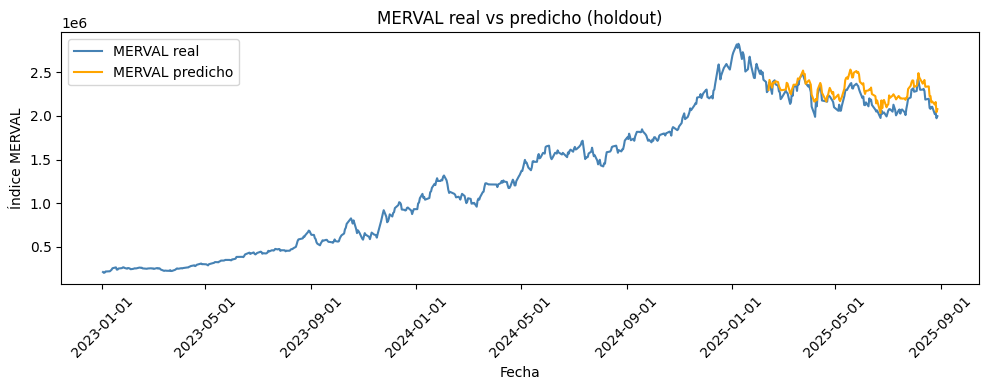

In [30]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df["fecha"], df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df["fecha"], df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


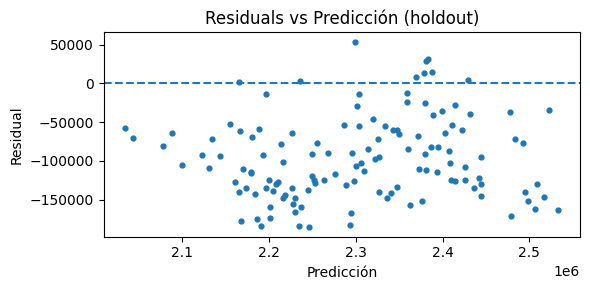

In [31]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


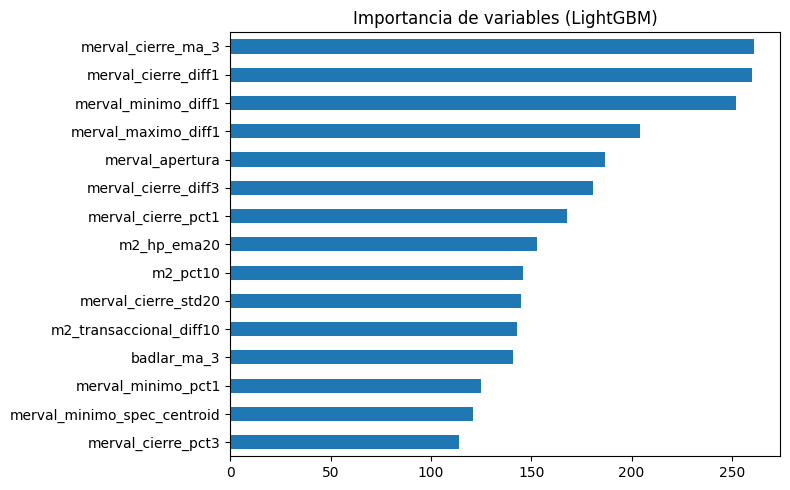

In [32]:
imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(15).plot(kind="barh", figsize=(8,5), title="Importancia de variables (LightGBM)")
plt.tight_layout()
plt.show()
